### Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your cleaned data
df = pd.read_csv("Online_Retail_Cleaned.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract month and year from date
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

print("Data loaded successfully!")
print(df.shape)

Data loaded successfully!
(397885, 12)


### Analysis 1 — Total Revenue by Month

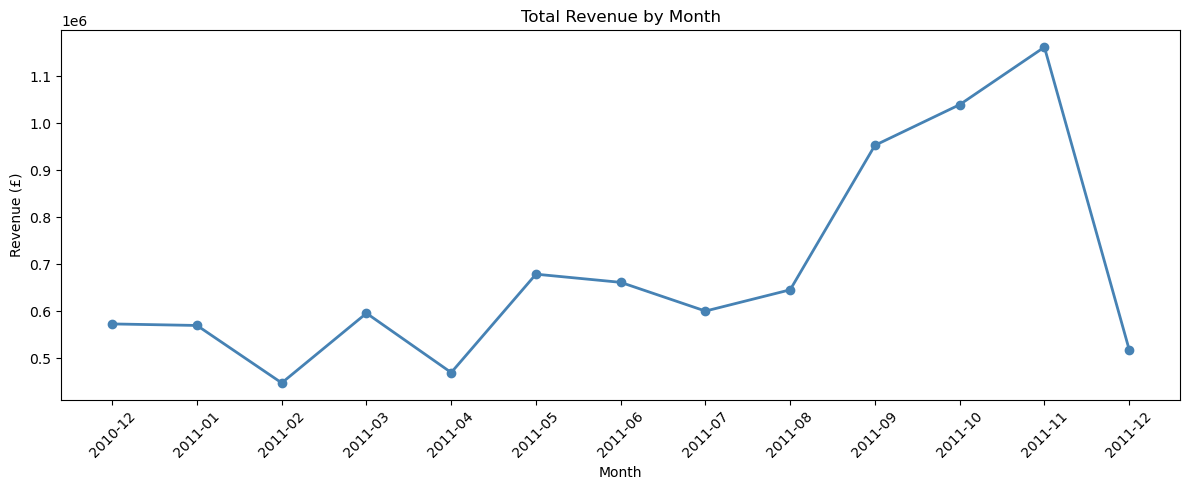

In [3]:
monthly_revenue = df.groupby('MonthYear')['Revenue'].sum().reset_index()
monthly_revenue['MonthYear'] = monthly_revenue['MonthYear'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['MonthYear'], monthly_revenue['Revenue'], 
         marker='o', color='steelblue', linewidth=2)
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analysis 2 — Top 10 Best Selling Products

C:\Users\DELL\AppData\Local\Temp\ipykernel_11668\2413540753.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Quantity', y='Description', palette='Blues_r')


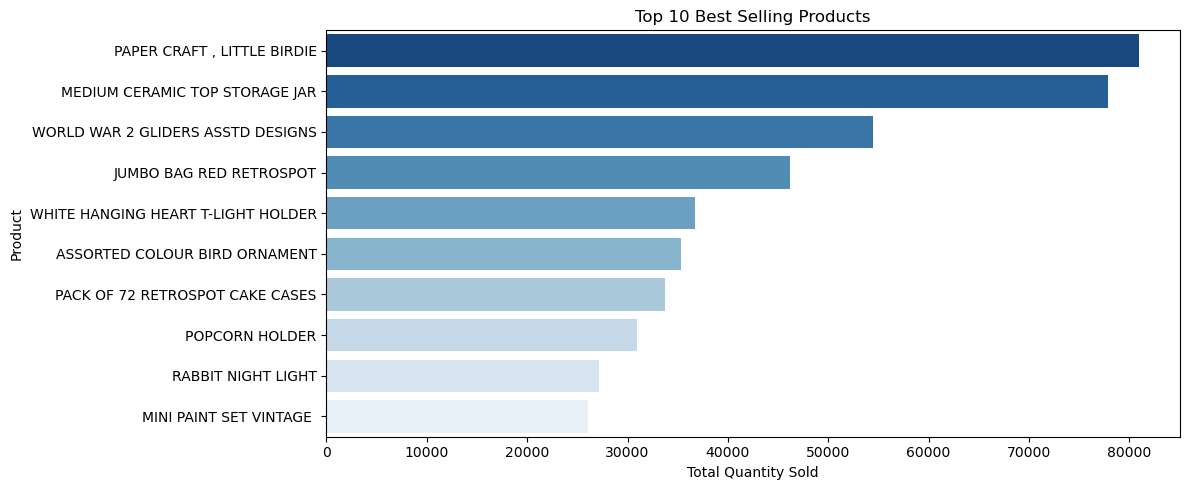

In [5]:
top_products = df.groupby('Description')['Quantity'].sum()
top_products = top_products.sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=top_products, x='Quantity', y='Description', palette='Blues_r')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

### Analysis 3 — Top 10 Products by Revenue

C:\Users\DELL\AppData\Local\Temp\ipykernel_11668\991503841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_revenue, x='Revenue', y='Description', palette='Greens_r')


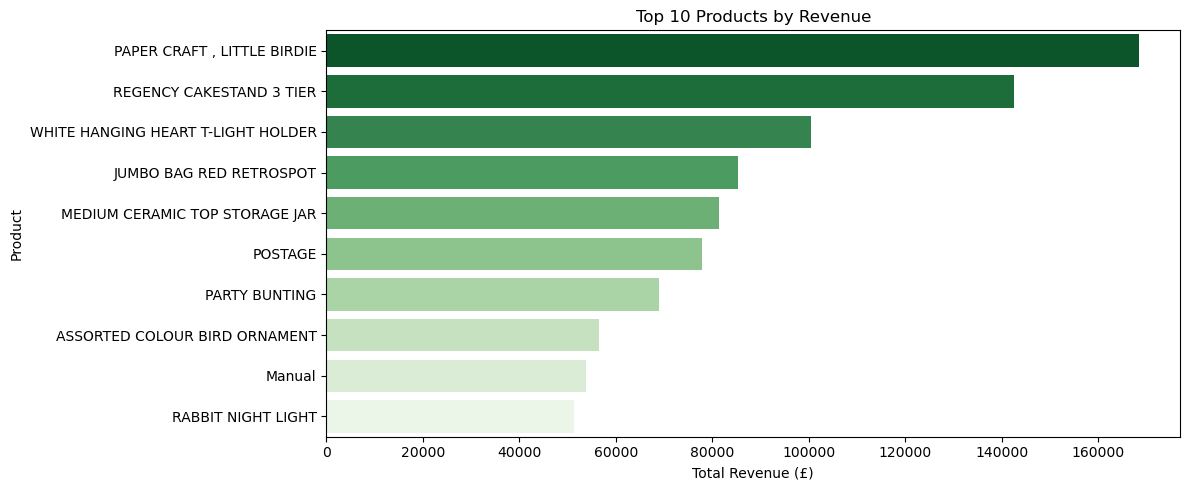

In [6]:
top_revenue = df.groupby('Description')['Revenue'].sum()
top_revenue = top_revenue.sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=top_revenue, x='Revenue', y='Description', palette='Greens_r')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

### Analysis 4 — Sales by Country

C:\Users\DELL\AppData\Local\Temp\ipykernel_11668\1964724655.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='Revenue', y='Country', palette='Oranges_r')


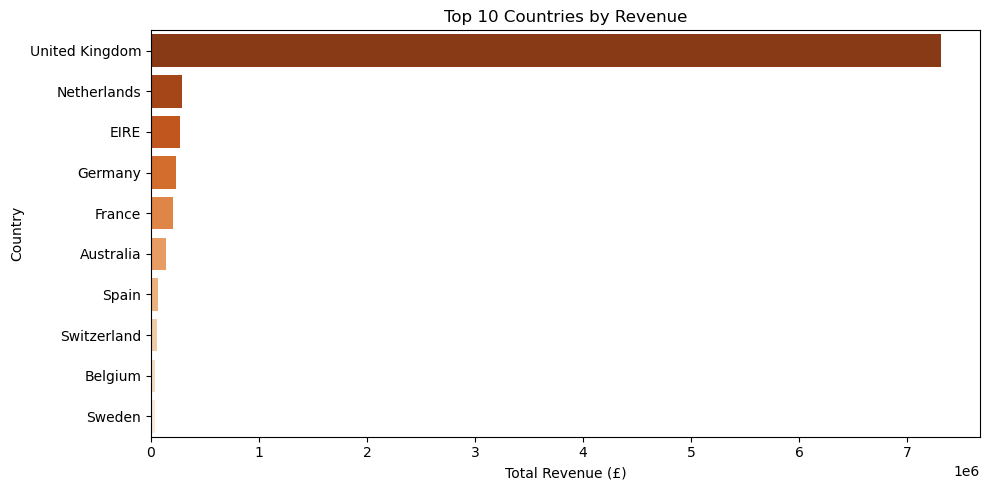

In [7]:
top_countries = df.groupby('Country')['Revenue'].sum()
top_countries = top_countries.sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_countries, x='Revenue', y='Country', palette='Oranges_r')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [10]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue', 'Month', 'Year',
       'MonthYear'],
      dtype='object')

### Analysis 5 — Number of Orders per Month

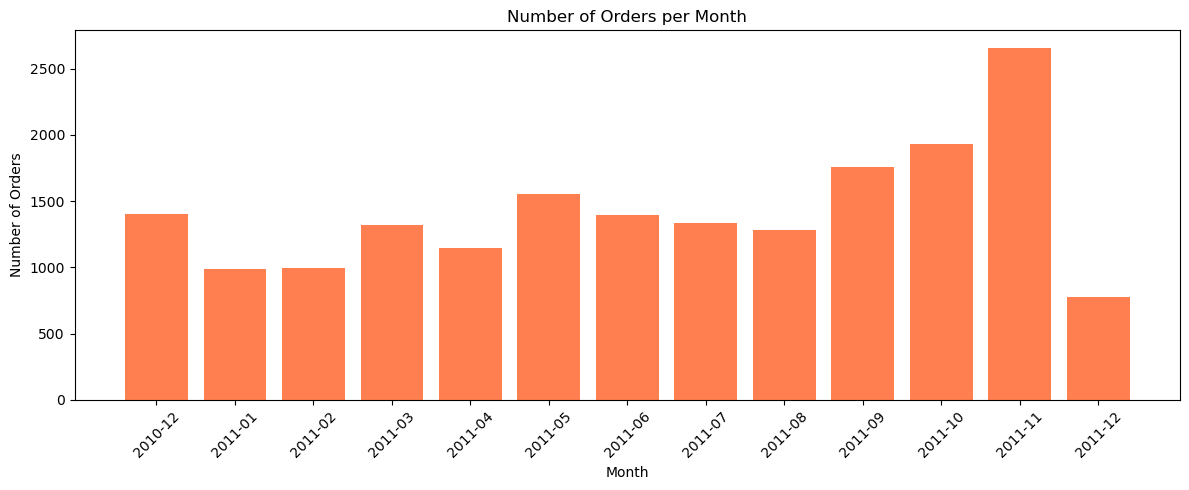

In [11]:
monthly_orders = df.groupby('MonthYear')['Invoice'].nunique().reset_index()
monthly_orders['MonthYear'] = monthly_orders['MonthYear'].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(monthly_orders['MonthYear'], monthly_orders['Invoice'], color='coral')
plt.title('Number of Orders per Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()